#3 - Preparing GDELT for Modelling: Variable-Level EDA & Preprocessing


This notebook performs a complete, variable-by-variable exploratory analysis of the cached
trade-specific GDELT slice before feature engineering, and records an explicit, justified
preprocessing decision for every field: missing-value treatment, variables to remove, variables
to retain, transformations, correlations, feature usefulness, and statistical assumptions. This notebook implements the Preprocessing described in Section 4.3 of the thesis.

In [55]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl, json
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":200,"font.size":11,"axes.grid":True,
    "grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False,
    "axes.titlesize":12,"axes.titleweight":"bold","figure.autolayout":True})
ACCENT="#1F3864"; ORANGE="#C55A11"; TEAL="#2E7D6F"; RED="#B22222"
DATA=Path("data"); FIG=Path("eda_figures"); FIG.mkdir(exist_ok=True)

ev = pd.read_parquet(DATA/"gdelt_corridor_trade.parquet")
# normalise BigQuery nullable Int64/Float64 -> numpy float for stats/plots
for c in ev.select_dtypes(include=["Int64","Float64"]).columns:
    ev[c]=ev[c].astype("float64")
ev['date']=pd.to_datetime(ev['SQLDATE'].astype(int).astype(str),format='%Y%m%d')
counts=json.load(open(DATA/"corridor_counts.json"))
ALL_CORRIDOR_EVENTS=counts['all_events']; TRADE_EVENTS=counts['trade_events']
print("Loaded:", ev.shape, "| trade share of corridor events: %.2f%%"%(100*TRADE_EVENTS/ALL_CORRIDOR_EVENTS))
ev.head(3)

Loaded: (1466103, 18) | trade share of corridor events: 2.83%


,GLOBALEVENTID,SQLDATE,Actor1CountryCode,Actor2CountryCode,Actor1Type1Code,Actor2Type1Code,IsRootEvent,EventCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_CountryCode,SOURCEURL,date
0,1.168362e+09,20240407.0,USA,USA,GOV,None,0.0,1031,10,3.0,-5.0,2.0,1.0,2.0,-2.255639,US,https://www.silive.com/news/2024/04/republican...,2024-04-07
1,1.075887e+09,20221212.0,KOR,JPN,None,None,0.0,1211,12,3.0,-4.0,2.0,1.0,2.0,-5.428571,JA,https://thefrontierpost.com/sino-taiwan-trade-...,2022-12-12
2,1.075887e+09,20221212.0,CHN,KOR,None,None,0.0,1211,12,3.0,-4.0,2.0,1.0,2.0,-5.428571,JA,https://thefrontierpost.com/sino-taiwan-trade-...,2022-12-12


In [56]:
# TWO-TIER DESIGN: features are built on Tier-1 UNION Tier-2 (training
# scope), because Tier-2 exists purely to enrich the rare positive class; evaluation/reporting is
# restricted to Tier-1 (the Novonesis-exposure lanes). Each row is tagged with its tier.
TIER1=[("EUR","USA"),("EUR","CHN"),("USA","CHN"),("USA","CAN"),("EUR","BRA"),("USA","BRA"),
 ("EUR","MEX"),("USA","MEX"),("EUR","IND"),("USA","IND"),("CHN","IND"),("CHN","BRA"),
 ("EUR","KOR"),("USA","KOR"),("EUR","JPN"),("CHN","JPN"),("CHN","KOR")]  # 17 (EUR-CAN is Tier-2 only)
TIER2=[("USA","JPN"),("CHN","CAN"),("EUR","CAN"),("CHN","MEX"),("JPN","KOR"),("IND","BRA")]  # 6
PAIRS_T1={frozenset(p) for p in TIER1}
PAIRS_T2={frozenset(p) for p in TIER2}
PAIRS_ALL=PAIRS_T1|PAIRS_T2   # training scope = 17 + 6 = 23 pairs
EU_ISO3=["AUT","BEL","BGR","HRV","CYP","CZE","DNK","EST","FIN","FRA","DEU","GRC","HUN","IRL",
 "ITA","LVA","LTU","LUX","MLT","NLD","POL","PRT","ROM","SVK","SVN","ESP","SWE","EUR"]  # ROM=Romania (CAMEO); EUR bloc code
ENTITY_TO_CODES={"EUR":EU_ISO3,"USA":["USA"],"CHN":["CHN"],"CAN":["CAN"],"BRA":["BRA"],
 "MEX":["MEX"],"IND":["IND"],"KOR":["KOR"],"JPN":["JPN"]}
code2ent={c:e for e,cs in ENTITY_TO_CODES.items() for c in cs}

# Validated trade CAMEO codes -> functional families
FEATURE_FAMILIES={
 'econ_coop':['061','071','0311','0331','0211','0231'],'econ_ease':['085','0354','0254'],
 'econ_demand':['1011','1031','1054'],'econ_reject':['1211','1221','1244'],
 'econ_threat':['1311','1312','1313','139'],'econ_coerce':['1621','163','191']}
CODE_TO_FAMILY={c:f for f,cs in FEATURE_FAMILIES.items() for c in cs}
print("Tier-1:",len(TIER1),"| Tier-2:",len(TIER2),"| training scope (union):",len(PAIRS_ALL),"pairs | families:",list(FEATURE_FAMILIES))

Tier-1: 17 | Tier-2: 6 | training scope (union): 23 pairs | families: ['econ_coop', 'econ_ease', 'econ_demand', 'econ_reject', 'econ_threat', 'econ_coerce']


In [57]:
from scipy.stats import skew
def profile(df):
    n=len(df); rows=[]
    for c in df.columns:
        s=df[c]; nn=int(s.notna().sum()); num=pd.api.types.is_numeric_dtype(s)
        rows.append({"variable":c,"dtype":str(s.dtype),"missing_%":round(100*(n-nn)/n,2),
            "n_unique":int(s.nunique(dropna=True)),
            "min":round(float(s.min()),2) if num else "",
            "max":round(float(s.max()),2) if num else "",
            "skew":round(float(skew(s.dropna())),2) if num and s.nunique()>2 else ""})
    return pd.DataFrame(rows)
prof=profile(ev); prof

,variable,dtype,missing_%,n_unique,min,max,skew
0,GLOBALEVENTID,float64,0.00,1466103,410399003.0,1315208475.0,0.03
1,SQLDATE,float64,0.00,4173,20150218.0,20260724.0,0.36
2,Actor1CountryCode,object,0.00,33,,,
3,Actor2CountryCode,object,0.00,33,,,
4,Actor1Type1Code,object,73.64,28,,,
5,Actor2Type1Code,object,72.07,28,,,
6,IsRootEvent,float64,0.00,2,0.0,1.0,
7,EventCode,object,0.00,20,,,
8,EventRootCode,object,0.00,10,,,
9,QuadClass,float64,0.00,4,1.0,4.0,1.55


Missing-value treatment: We quantify it and decide a treatment per field.

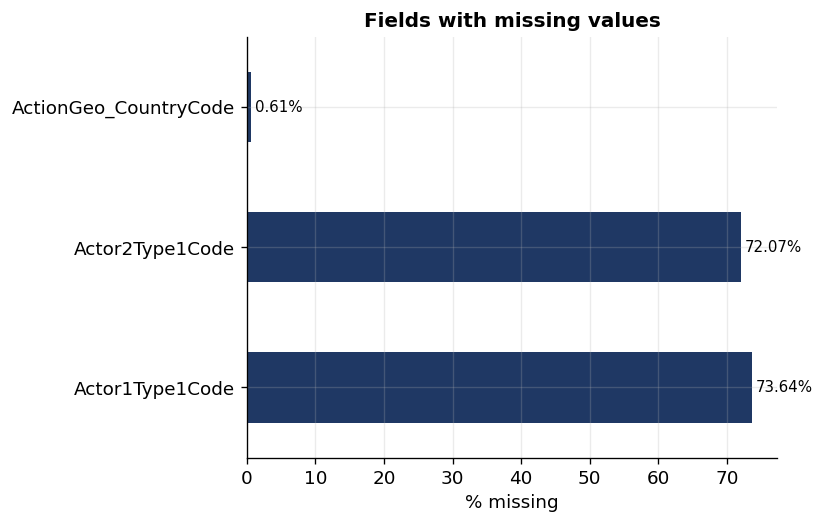

Actor1Type1Code          73.64
Actor2Type1Code          72.07
ActionGeo_CountryCode     0.61


In [58]:
miss=(ev.isna().mean()*100).round(2).sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(7,4.5)); miss[miss>0].plot.barh(ax=ax,color=ACCENT)
ax.set_xlabel("% missing"); ax.set_title("Fields with missing values")
for i,v in enumerate(miss[miss>0]): ax.text(v+0.5,i,f"{v}%",va='center',fontsize=9)
plt.savefig(FIG/"prep_missing.png",bbox_inches='tight'); plt.show()
print(miss[miss>0].to_string())

In [59]:
# Treatment: actor-type fields are missing when GDELT cannot type an actor -> the missingness is
# itself informative (structurally MNAR). Recode as a binary 'typed' indicator rather than impute
# or drop 70%+ of rows (Little & Rubin, 2019). ActionGeo missing (0.6%) is negligible.
ev['Actor1_typed']=ev['Actor1Type1Code'].notna().astype(int)
ev['Actor2_typed']=ev['Actor2Type1Code'].notna().astype(int)
print("Actor1 typed share: %.1f%% | Actor2 typed share: %.1f%%"%(100*ev['Actor1_typed'].mean(),100*ev['Actor2_typed'].mean()))
print("ActionGeo_CountryCode missing: %.2f%% -> retain; drop the <1%% for any geo-specific step."%(ev['ActionGeo_CountryCode'].isna().mean()*100))

Actor1 typed share: 26.4% | Actor2 typed share: 27.9%
ActionGeo_CountryCode missing: 0.61% -> retain; drop the <1% for any geo-specific step.


In [60]:
decisions=[
 ("GLOBALEVENTID","remove (from features)","Unique row identifier; no predictive content; keep only for provenance."),
 ("SQLDATE / date","retain (as key)","Temporal key for aggregation and for the leakage-safe window; not a feature itself."),
 ("Actor1CountryCode","retain (grouping)","Defines corridor origin; used to map events to entity pairs."),
 ("Actor2CountryCode","retain (grouping)","Defines corridor partner; used to map events to entity pairs."),
 ("Actor1Type1Code","transform","72-74% missing -> replaced by presence indicator Actor1_typed."),
 ("Actor2Type1Code","transform","-> presence indicator Actor2_typed."),
 ("IsRootEvent","use then drop","De-duplication flag: 37.9% are non-root repeats; used to de-duplicate, not a feature."),
 ("EventCode","retain (core)","Maps to the six validated CAMEO families - the substantive signal."),
 ("EventRootCode","remove","Deterministic 2-digit prefix of EventCode -> redundant with family mapping."),
 ("QuadClass","retain (coarse)","Cooperation/conflict quadrant; complements family counts as a coarse signal."),
 ("GoldsteinScale","remove","Deterministic lookup from EventCode (Goldstein, 1992) -> collinear; no new info."),
 ("NumMentions","remove","Redundancy-inflated; near-perfectly correlated with NumArticles -> superseded by NumSources."),
 ("NumArticles","remove","Near-duplicate of NumMentions (see Section 5)."),
 ("NumSources","retain + log","De-duplicated attention measure; right-skewed -> log1p transform."),
 ("AvgTone","retain","Continuous document sentiment; the one feature orthogonal to event type."),
 ("ActionGeo_CountryCode","optional / drop","FIPS geography (distinct code system); not central; excluded from baseline features."),
 ("SOURCEURL","remove (from features)","Provenance / de-dup key only; not a feature."),
]
dec=pd.DataFrame(decisions,columns=["variable","decision","justification"]); dec

,variable,decision,justification
0,GLOBALEVENTID,remove (from features),Unique row identifier; no predictive content; ...
1,SQLDATE / date,retain (as key),Temporal key for aggregation and for the leaka...
2,Actor1CountryCode,retain (grouping),Defines corridor origin; used to map events to...
3,Actor2CountryCode,retain (grouping),Defines corridor partner; used to map events t...
4,Actor1Type1Code,transform,72-74% missing -> replaced by presence indicat...
5,Actor2Type1Code,transform,-> presence indicator Actor2_typed.
6,IsRootEvent,use then drop,De-duplication flag: 37.9% are non-root repeat...
7,EventCode,retain (core),Maps to the six validated CAMEO families - the...
8,EventRootCode,remove,Deterministic 2-digit prefix of EventCode -> r...
9,QuadClass,retain (coarse),Cooperation/conflict quadrant; complements fam...


Skewness:
 GoldsteinScale    -2.90
AvgTone           -0.19
NumMentions       12.98
NumSources        55.81
NumArticles       13.71
QuadClass          1.55


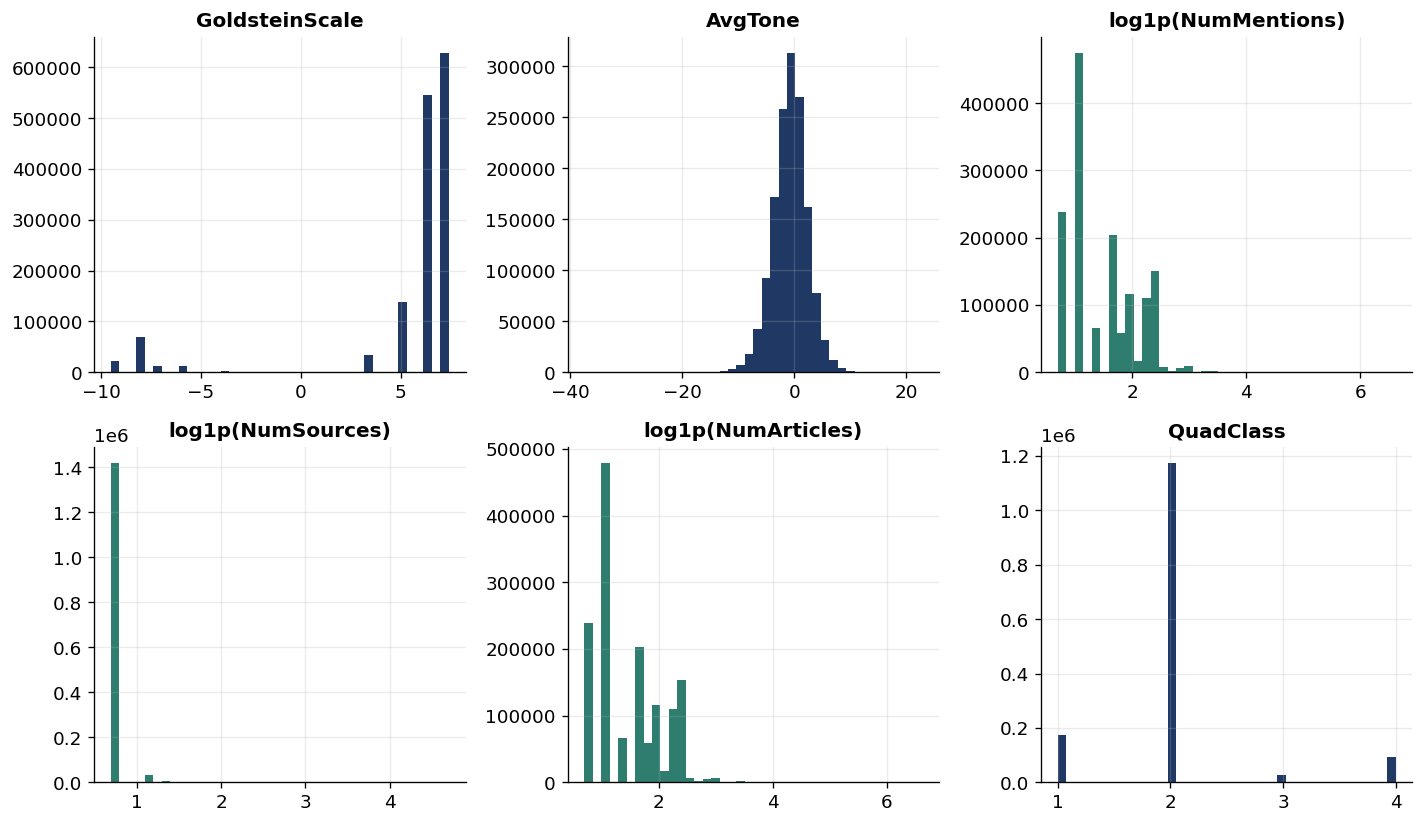

In [61]:
num=['GoldsteinScale','AvgTone','NumMentions','NumSources','NumArticles','QuadClass']
sk=pd.Series({c:skew(ev[c].dropna()) for c in num}).round(2)
print("Skewness:\n",sk.to_string())
fig,axes=plt.subplots(2,3,figsize=(12,7))
for ax,c in zip(axes.ravel(),num):
    x=ev[c].dropna()
    if c in ['NumMentions','NumSources','NumArticles']:
        ax.hist(np.log1p(x),bins=40,color=TEAL); ax.set_title(f"log1p({c})")
    else:
        ax.hist(x,bins=40,color=ACCENT); ax.set_title(c)
plt.savefig(FIG/"prep_distributions.png",bbox_inches='tight'); plt.show()

In [62]:
# Effect of the log transform on the count fields (skewness before vs after)
for c in ['NumMentions','NumSources','NumArticles']:
    before=skew(ev[c].dropna()); after=skew(np.log1p(ev[c].dropna()))
    print(f"{c:12s}: skew {before:6.2f} -> log1p {after:6.2f}")
ev['log_NumSources']=np.log1p(ev['NumSources'])

NumMentions : skew  12.98 -> log1p   0.51
NumSources  : skew  55.81 -> log1p   9.04
NumArticles : skew  13.71 -> log1p   0.49


The attention counts are heavily right-skewed (long duplication tails);
a log1p transform is the standard remedy for count features feeding a linear model. It reduces skew markedly for NumMentions and NumArticles; NumSources retains
a heavier tail even after transformation, so it is additionally standardised at the modelling stage. AvgTone is approximately symmetric and
is kept as-is (optionally winsorised at extreme tails). GoldsteinScale and QuadClass are
discrete and are not transformed. Continuous features will be standardised at the modelling
stage, which is required for penalised logistic regression so the penalty treats coefficients
comparably 

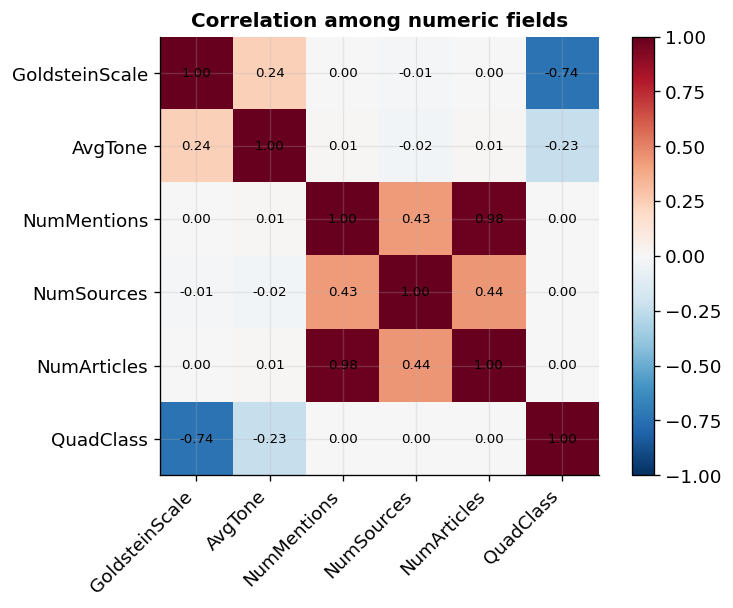

Pairs with |r|>0.8 (redundant): [('NumMentions', 'NumArticles', np.float64(0.981))]


In [63]:
#Correlations, redundancy, and multicollinearity
corr=ev[num].corr()
fig,ax=plt.subplots(figsize=(6.5,5.2)); im=ax.imshow(corr,cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num,rotation=45,ha='right')
ax.set_yticks(range(len(num))); ax.set_yticklabels(num)
for (i,j),v in np.ndenumerate(corr.values): ax.text(j,i,f"{v:.2f}",ha='center',va='center',fontsize=8)
plt.colorbar(im,fraction=0.046); ax.set_title("Correlation among numeric fields")
plt.savefig(FIG/"prep_correlation.png",bbox_inches='tight'); plt.show()
hi=[(num[i],num[j],round(corr.values[i,j],3)) for i in range(len(num)) for j in range(i+1,len(num)) if abs(corr.values[i,j])>0.8]
print("Pairs with |r|>0.8 (redundant):",hi)

In [64]:
# GoldsteinScale is a deterministic function of the event code -> zero within-code variance
g=ev.groupby('EventCode')['GoldsteinScale'].agg(['nunique','std']).fillna(0)
print("EventCodes where GoldsteinScale varies at all:", int((g['nunique']>1).sum()), "of", len(g))
print("Mean within-code std of GoldsteinScale: %.4f (==0 => fully determined by EventCode)"%g['std'].mean())

EventCodes where GoldsteinScale varies at all: 9 of 20
Mean within-code std of GoldsteinScale: 0.0000 (==0 => fully determined by EventCode)


In [65]:
# Variance inflation factors on the candidate numeric feature set (raw vs after pruning)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
def vif_table(df, cols):
    X=add_constant(df[cols].dropna().astype(float))
    return pd.Series({c:variance_inflation_factor(X.values,i) for i,c in enumerate(X.columns) if c!='const'}).round(2)
print("VIF - full numeric set:"); print(vif_table(ev,num).to_string())
pruned=['AvgTone','log_NumSources','QuadClass']
print("\nVIF - after removing GoldsteinScale/NumMentions/NumArticles and log-transforming sources:")
print(vif_table(ev,pruned).to_string())

VIF - full numeric set:
GoldsteinScale     2.23
AvgTone            1.07
NumMentions       25.93
NumSources         1.24
NumArticles       26.30
QuadClass          2.23

VIF - after removing GoldsteinScale/NumMentions/NumArticles and log-transforming sources:
AvgTone           1.06
log_NumSources    1.00
QuadClass         1.06


In [66]:
def nzv(df, cols):
    out=[]
    for c in cols:
        s=df[c].dropna(); vc=s.value_counts()
        freq_ratio=(vc.iloc[0]/vc.iloc[1]) if len(vc)>1 else np.inf
        pct_unique=100*s.nunique()/len(s)
        out.append({"variable":c,"freq_ratio":round(freq_ratio,1),"pct_unique":round(pct_unique,4),
                    "near_zero_var": bool(freq_ratio>19 and pct_unique<10)})
    return pd.DataFrame(out)
nzv(ev, num+['IsRootEvent','Actor1_typed','Actor2_typed']).sort_values('freq_ratio',ascending=False)

,variable,freq_ratio,pct_unique,near_zero_var
1,AvgTone,56.2,11.9177,False
3,NumSources,43.8,0.0027,True
5,QuadClass,6.8,0.0003,False
7,Actor1_typed,2.8,0.0001,False
8,Actor2_typed,2.6,0.0001,False
4,NumArticles,2.0,0.0092,False
2,NumMentions,2.0,0.0095,False
6,IsRootEvent,1.6,0.0001,False
0,GoldsteinScale,1.1,0.0013,False


In [67]:
# De-duplicate (root events) and restrict to the TRAINING SCOPE = Tier-1 U Tier-2 (23 pairs);
# tag each event with its tier so evaluation can later be restricted to Tier-1.
evr = ev[ev['IsRootEvent']==1].copy()
evr['e1']=evr['Actor1CountryCode'].map(code2ent); evr['e2']=evr['Actor2CountryCode'].map(code2ent)
evr['pair']=evr.apply(lambda r: tuple(sorted((r['e1'],r['e2']))) if pd.notna(r['e1']) and pd.notna(r['e2']) else None,axis=1)
evr=evr[evr['pair'].apply(lambda pr: pr is not None and frozenset(pr) in PAIRS_ALL)]
evr['tier']=evr['pair'].apply(lambda pr: 'T1' if frozenset(pr) in PAIRS_T1 else 'T2')
evr['family']=evr['EventCode'].map(CODE_TO_FAMILY)
evr['month']=evr['date'].values.astype('datetime64[M]')
evr['pair_str']=evr['pair'].apply(lambda pr:"-".join(pr))
print("Root events in Tier-1 U Tier-2:", len(evr),
      "| T1:",int((evr['tier']=='T1').sum()),"T2:",int((evr['tier']=='T2').sum()),
      "| distinct corridors:", evr['pair_str'].nunique())

Root events in Tier-1 U Tier-2: 393560 | T1: 339221 T2: 54339 | distinct corridors: 23


In [68]:
#Monthly aggregation: family counts + total volume + mean tone + summed log-sources; attach tier
fam_counts=(evr.pivot_table(index=['pair_str','month'],columns='family',values='GLOBALEVENTID',
            aggfunc='count',fill_value=0).reindex(columns=list(FEATURE_FAMILIES),fill_value=0))
extra=evr.groupby(['pair_str','month']).agg(total_events=('GLOBALEVENTID','count'),
            avg_tone=('AvgTone','mean'), sum_log_sources=('log_NumSources','sum')).astype(float)
feat=fam_counts.join(extra).sort_index()
pair_tier=evr.drop_duplicates('pair_str').set_index('pair_str')['tier'].to_dict()
feat['tier']=feat.index.get_level_values('pair_str').map(pair_tier)
print("Corridor-month base matrix:", feat.shape, "| corridor-months by tier:", feat['tier'].value_counts().to_dict())
feat.head(6)

Corridor-month base matrix: (3088, 10) | corridor-months by tier: {'T1': 2343, 'T2': 745}


econ_coop  econ_ease  econ_demand  econ_reject  \
pair_str month                                                        
BRA-CHN  2015-02-01         28          0            0            0   
         2015-03-01         43          0            0            0   
         2015-04-01         42          0            0            0   
         2015-05-01        340          2            0            0   
         2015-06-01        114          0            0            0   
         2015-07-01         71          3            0            0   

                     econ_threat  econ_coerce  total_events  avg_tone  \
pair_str month                                                          
BRA-CHN  2015-02-01            0            0          28.0  0.475032   
         2015-03-01            0            0          43.0  0.373092   
         2015-04-01            0            0          42.0 -0.455922   
         2015-05-01            0            4         346.0  0.616642   
         2015-06-01            0            2         116.0  0.079981   
         2015-07-01            0            0          74.0 -0.567343   

                     sum_log_sources tier  
pair_str month                             
BRA-CHN  2015-02-01        19.408121   T1  
         2015-03-01        29.805329   T1  
         2015-04-01        29.517647   T1  
         2015-05-01       242.298083   T1  
         2015-06-01        80.810538   T1  
         2015-07-01        51.698356   T1

In [69]:
#HARMONISED horizon features: for each family, a trailing-window RATE over w in {1,2,3} 
fams=list(FEATURE_FAMILIES); REF='econ_coop'
def roll_sum(cols,w):
    return (feat.groupby(level='pair_str')[cols].rolling(w,min_periods=1).sum().reset_index(level=0,drop=True))
rate_cols=[]
for w in [1,2,3]:
    fam_w=roll_sum(fams,w); tot_w=roll_sum(['total_events'],w)['total_events']
    for f in fams:
        if f==REF: continue
        col=f"{f}_rate_{w}m"; feat[col]=(fam_w[f]/tot_w.replace(0,np.nan)).fillna(0); rate_cols.append(col)
print("Harmonised windowed-rate features:", len(rate_cols), "(5 families x 1/2/3-month; econ_coop=reference)")
print("Sparsity (all-zero cells among base family counts): %.1f%%"%(100*(fam_counts.values==0).mean()))
feat.filter(regex='econ_threat_rate').head(6)

Harmonised windowed-rate features: 15 (5 families x 1/2/3-month; econ_coop=reference)
Sparsity (all-zero cells among base family counts): 64.7%


econ_threat_rate_1m  econ_threat_rate_2m  \
pair_str month                                                  
BRA-CHN  2015-02-01                  0.0                  0.0   
         2015-03-01                  0.0                  0.0   
         2015-04-01                  0.0                  0.0   
         2015-05-01                  0.0                  0.0   
         2015-06-01                  0.0                  0.0   
         2015-07-01                  0.0                  0.0   

                     econ_threat_rate_3m  
pair_str month                            
BRA-CHN  2015-02-01                  0.0  
         2015-03-01                  0.0  
         2015-04-01                  0.0  
         2015-05-01                  0.0  
         2015-06-01                  0.0  
         2015-07-01                  0.0

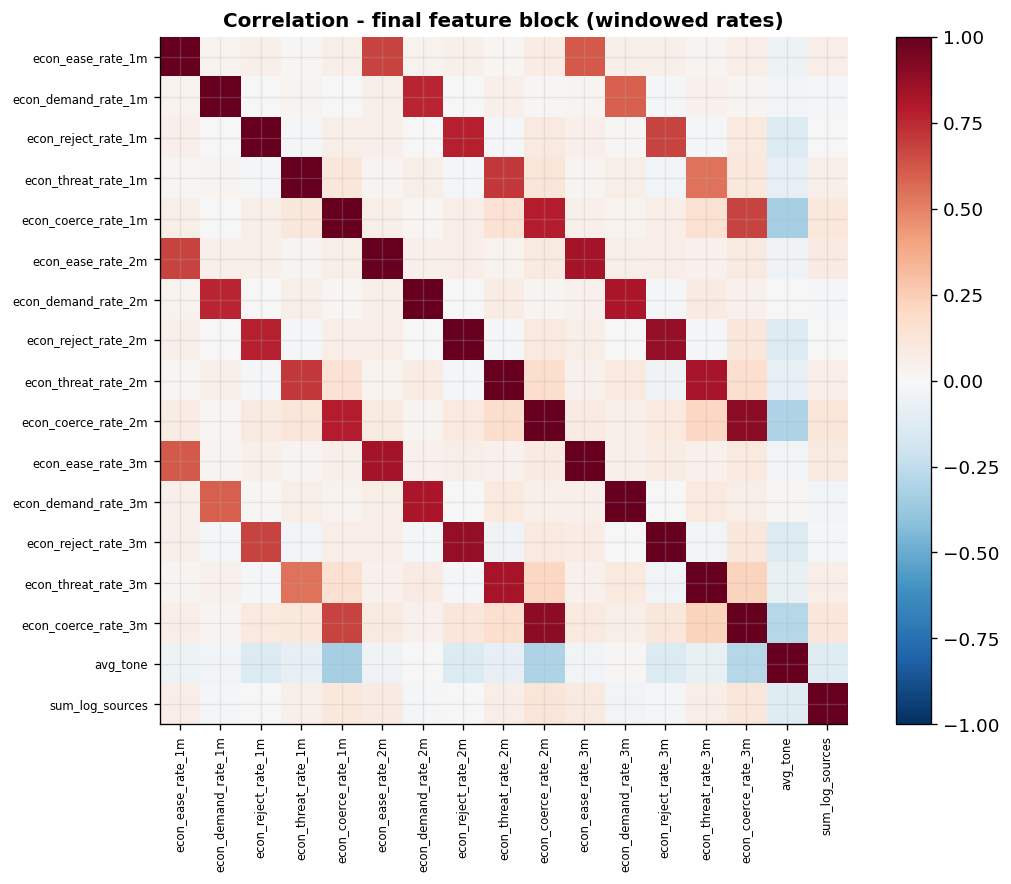

VIF (final block) - finite (closure resolved); cross-window family VIFs>1 are expected & penalised:
econ_coerce_rate_2m    7.40
econ_reject_rate_2m    6.02
econ_coerce_rate_3m    5.29
econ_demand_rate_2m    4.72
econ_threat_rate_2m    4.51
econ_reject_rate_3m    4.40
econ_ease_rate_2m      3.75
econ_threat_rate_3m    3.31
econ_ease_rate_3m      3.29
econ_demand_rate_3m    3.06
econ_coerce_rate_1m    2.75
econ_reject_rate_1m    2.55
econ_demand_rate_1m    2.45
econ_threat_rate_1m    2.01
econ_ease_rate_1m      1.88
avg_tone               1.17
sum_log_sources        1.04


In [70]:
#Correlation & VIF on the final continuous feature block (windowed rates + tone + attention)
final_num=rate_cols+['avg_tone','sum_log_sources']
c2=feat[final_num].corr()
fig,ax=plt.subplots(figsize=(9,7.5)); im=ax.imshow(c2,cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(len(final_num))); ax.set_xticklabels(final_num,rotation=90,fontsize=7)
ax.set_yticks(range(len(final_num))); ax.set_yticklabels(final_num,fontsize=7)
plt.colorbar(im,fraction=0.046); ax.set_title("Correlation - final feature block (windowed rates)")
plt.savefig(FIG/"prep_feature_corr.png",bbox_inches='tight'); plt.show()
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X=add_constant(feat[final_num].fillna(0).astype(float))
vif=pd.Series({c:variance_inflation_factor(X.values,i) for i,c in enumerate(X.columns) if c!='const'}).round(2)
print("VIF (final block) - finite (closure resolved); cross-window family VIFs>1 are expected & penalised:")
print(vif.sort_values(ascending=False).to_string())

In [71]:
final=[
 ("econ_{ease,demand,reject,threat,coerce}_rate_{1,2,3}m","15 windowed family rates (5 families x 1/2/3-month; econ_coop=reference)","core signal; drift-controlled & horizon-matched (Aitchison, 1982)"),
 ("avg_tone","mean AvgTone per corridor-month","continuous sentiment, orthogonal to event type"),
 ("sum_log_sources","summed log1p(NumSources)","de-duplicated media attention"),
 ("tier (T1/T2)","corridor tier tag","train on T1 U T2; evaluate/report on T1 only (Table 3.1)"),
 ("(keys) pair_str, month","corridor & period identifiers","grouping / temporal split; not model inputs"),
]
final_df=pd.DataFrame(final,columns=["feature(s)","description","rationale"])
print("Feature-matrix shape:", feat.shape, "| continuous model features:", len(final_num))
print("Corridor-months: total %d (T1 %d, T2 %d) across %d corridors"%(len(feat),
      int((feat['tier']=='T1').sum()),int((feat['tier']=='T2').sum()),
      feat.index.get_level_values('pair_str').nunique()))
print("REMOVED from features: GLOBALEVENTID, EventRootCode, GoldsteinScale, NumMentions, NumArticles,")
print("                       SOURCEURL, ActionGeo_CountryCode, raw Actor*Type1Code (recoded).")
feat.to_parquet(DATA/"gdelt_features_monthly.parquet")  # for Task 5 label join
print("saved -> data/gdelt_features_monthly.parquet")
final_df

Feature-matrix shape: (3088, 25) | continuous model features: 17
Corridor-months: total 3088 (T1 2343, T2 745) across 23 corridors
REMOVED from features: GLOBALEVENTID, EventRootCode, GoldsteinScale, NumMentions, NumArticles,
                       SOURCEURL, ActionGeo_CountryCode, raw Actor*Type1Code (recoded).
saved -> data/gdelt_features_monthly.parquet


,feature(s),description,rationale
0,"econ_{ease,demand,reject,threat,coerce}_rate_{...",15 windowed family rates (5 families x 1/2/3-m...,core signal; drift-controlled & horizon-matche...
1,avg_tone,mean AvgTone per corridor-month,"continuous sentiment, orthogonal to event type"
2,sum_log_sources,summed log1p(NumSources),de-duplicated media attention
3,tier (T1/T2),corridor tier tag,train on T1 U T2; evaluate/report on T1 only (...
4,"(keys) pair_str, month",corridor & period identifiers,grouping / temporal split; not model inputs
